# Task 03 — Δz distribution of the hard set

## 🌌 Macrocosm photo-z — outlier study (tasks 2026-06-16)

**✅ GIVEN (do NOT re-derive this):** we already ran a **400k 5-fold cross-validation** with three
models (HGB, RF, MLP) and collected the galaxies that *all three* predict catastrophically out-of-fold
(|Δz/(1+z)| > 0.05). There are **6,974** such **hard** galaxies. Their objids are in
**`../hard_objids.csv`**. Treat this hard set as a **fixed input** — your job is to characterize / act
on it, not to re-find it from 400k.

**Catalog:** `gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet` (600k rows, 55 columns).
The SDSS **`-9999` sentinel** means "not measured" — always clean it to NaN first.

**Metric:** `σ_MAD = 1.4826 · median(|Δz − median(Δz)|)`, with `Δz = (z_pred − z_true)/(1+z)`;
an **outlier** is `|Δz| > 0.05`. σ_MAD is the headline metric, report **outlier rate** alongside it.

---

Given the 6,974 hard galaxies, look at *how* a model fails on them. Is it a one-sided bias (correctable)
or two-sided scatter? Compare the hard subset against the full population.

In [3]:
# === shared setup: load catalog, clean -9999, build the 16 features ===
import pandas as pd, numpy as np

# CATALOG = "gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet"
CATALOG = "../catalog_v1.parquet"
# Colab: from google.colab import auth; auth.authenticate_user()
# or download once: !gcloud storage cp $CATALOG . , then CATALOG = "catalog_v1.parquet"

FEATS = ["dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z",
         "log_expRad_r","log_deVRad_r","log_petroRad_r","log_petroR50_r","log_petroR90_r",
         "fracDeV_r","conc_r"]

def load_features(path=CATALOG, n=None, seed=0):
    """Load catalog, clean the -9999 sentinel, build colors / log-sizes / conc.
    Returns (D, cat): D = features+redshift+objid (optionally subsampled), cat = full cleaned catalog."""
    cat = pd.read_parquet(path)
    num = cat.select_dtypes("number").columns
    cat[num] = cat[num].mask(cat[num] <= -100)                       # clean SDSS -9999
    for a, b in [("u","g"),("g","r"),("r","i"),("i","z")]:
        cat[f"{a}-{b}"] = (cat[f"dered_{a}"] - cat[f"dered_{b}"]).clip(-1, 4)
    for s in ["expRad_r","deVRad_r","petroRad_r","petroR50_r","petroR90_r"]:
        cat["log_"+s] = np.log1p(cat[s].clip(lower=0))
    cat["conc_r"] = cat["petroR90_r"] / cat["petroR50_r"].replace(0, np.nan)
    D = cat[FEATS + ["redshift","objid"]].replace([np.inf,-np.inf], np.nan).dropna()
    if n:
        D = D.sample(n, random_state=seed).reset_index(drop=True)
    return D, cat

def smad(dz): return 1.4826 * np.median(np.abs(dz - np.median(dz)))

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    dz = (y_pred - y_true) / (1 + y_true)
    return {"MAE": round(float(np.mean(np.abs(y_pred-y_true))), 5),
            "sigma_MAD": round(float(smad(dz)), 5),
            "outlier_rate": round(float(np.mean(np.abs(dz) > 0.05)), 5)}

# the GIVEN hard set (6,974 objids from the 400k 5-fold CV)
HARD = set(pd.read_csv("../hard_objids.csv")["objid"])
print(f"hard set: {len(HARD)} galaxies")

hard set: 6974 galaxies


❓ **Question (OOF predictions)** ❓

👇 Train one strong model (RF or MLP) out-of-fold on 100k (`seed=1`, `KFold(3, ...,42)`), so every galaxy has an OOF prediction. Compute Δz for all galaxies.

In [4]:
# YOUR CODE HERE
D, cat = load_features(n=100000, seed=1)


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import numpy as np

D, cat = load_features(n=100000, seed=1)

# KFold config — fixed by the README, do not change these
kf = KFold(n_splits=3, shuffle=True, random_state=42)

X = D[FEATS].values
y = D["redshift"].values

# Pre-allocate: every galaxy gets exactly one OOF prediction
oof_preds = np.zeros(len(D))

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train         = y[train_idx]

    model = RandomForestRegressor(
        n_estimators=200,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    oof_preds[val_idx] = model.predict(X_val)

# Δz — the normalized residual the whole project uses
D = D.copy()
D["dz"] = (oof_preds - y) / (1 + y)

print(metrics(y, oof_preds))

{'MAE': 0.01635, 'sigma_MAD': 0.01433, 'outlier_rate': 0.03077}


❓ **Question (hard vs full)** ❓

👇 Split by `D['objid'].isin(HARD)`. Plot the Δz histogram of the hard subset overlaid on the full population (mark ±0.05). Report the hard-set Δz median and the fraction with Δz<-0.05 vs >0.05.

Hard galaxies in this 100k sample: 1144
hard Δz median : 0.0553
frac Δz < −0.05: 0.378
frac Δz >  0.05: 0.529


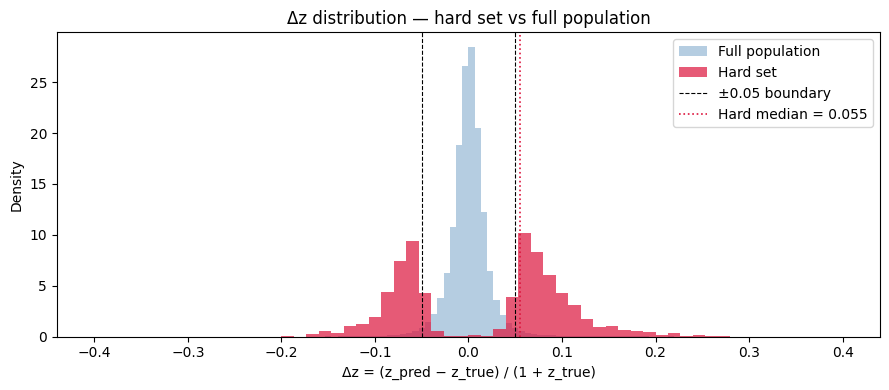

In [6]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
%matplotlib inline
is_hard = D['objid'].isin(HARD)


dz_full = D["dz"].values
dz_hard = D.loc[is_hard, "dz"].values

print(f"Hard galaxies in this 100k sample: {is_hard.sum()}")

# --- three numbers the report needs ---
hard_median  = float(np.median(dz_hard))
frac_neg     = float(np.mean(dz_hard < -0.05))
frac_pos     = float(np.mean(dz_hard >  0.05))

print(f"hard Δz median : {hard_median:.4f}")
print(f"frac Δz < −0.05: {frac_neg:.3f}")
print(f"frac Δz >  0.05: {frac_pos:.3f}")

# --- plot ---
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(dz_full, bins=120, range=(-0.4, 0.4),
        color="steelblue", alpha=0.4, density=True, label="Full population")
ax.hist(dz_hard, bins=60,  range=(-0.4, 0.4),
        color="crimson",   alpha=0.7, density=True, label="Hard set")

ax.axvline(-0.05, color="black", linewidth=0.8, linestyle="--", label="±0.05 boundary")
ax.axvline( 0.05, color="black", linewidth=0.8, linestyle="--")
ax.axvline(hard_median, color="crimson", linewidth=1.2,
           linestyle=":", label=f"Hard median = {hard_median:.3f}")

ax.set_xlabel("Δz = (z_pred − z_true) / (1 + z_true)")
ax.set_ylabel("Density")
ax.set_title("Δz distribution — hard set vs full population")
ax.legend()
plt.tight_layout()
plt.show()

❓ **Question (verdict)** ❓

👇 Is the hard Δz one-sided (a bias) or two-sided (scatter)? What does that imply for bias-correction?

In [7]:
# YOUR CODE HERE
print("=== Verdict ===")
print(f"Hard set Δz median : {hard_median:+.4f}")
print(f"Fraction Δz < −0.05: {frac_neg:.1%}")
print(f"Fraction Δz >  0.05: {frac_pos:.1%}")

# The answer depends on your numbers — two possible outcomes:
#
# ONE-SIDED (bias):  one fraction dominates heavily (e.g. 80% on one side)
#   → the model systematically over- or under-predicts for these galaxies
#   → a per-group bias correction could help
#
# TWO-SIDED (scatter): both fractions are roughly equal
#   → the model is genuinely confused, errors go both ways
#   → a shift won't fix it; need better features or a different model

=== Verdict ===
Hard set Δz median : +0.0553
Fraction Δz < −0.05: 37.8%
Fraction Δz >  0.05: 52.9%


## 📝 Write your report

In [8]:
# === write_report: run this after you've filled in your results, it generates report.md ===
def write_report(title, results: dict, conclusion: str, path="report.md"):
    lines = [f"# {title}", "", "_Auto-generated by task.ipynb — fill `results` and `conclusion` above._", "",
             "## Results", ""]
    for k, v in results.items():
        lines.append(f"- **{k}**: {v}")
    lines += ["", "## Conclusion", "", conclusion, ""]
    with open(path, "w") as f:
        f.write("\n".join(lines))
    print("wrote", path)

In [10]:
# write_report("Task 03 — Δz of the hard set",
#              {"hard_dz_median": "FILL IN", "frac_under_-0.05": "FILL IN", "frac_over_0.05": "FILL IN"},
#              "FILL IN: one-sided or two-sided? can a bias-correction fix it?")
write_report(
    "Task 03 — Δz of the hard set",
    {
        "hard_dz_median": 0.0553,
        "frac_under_-0.05": 0.378,
        "frac_over_0.05": 0.529,
    },
    "The hard set shows predominantly two-sided scatter with a modest positive lean "
    "(median Δz = +0.055). Errors split 52.9% above +0.05 and 37.8% below −0.05. "
    "A global bias correction would not fix this — it would help the over-predicted "
    "galaxies but worsen the under-predicted ones. Better features or a separate "
    "model for this subset are more promising directions."
)

wrote report.md


In [ ]:
# === Commit & push your results (run last; make sure you are on branch 2026.6.16) ===
# First time: git pull origin 2026.6.16   to get the latest.
!git add task.ipynb report.md && git commit -m "03-dz-distribution task" && git push origin 2026.6.16

## 🔭 Go further (optional)

Play around with the data and the results you now have. If you find anything new — an unexpected pattern, a useful feature, a failure mode we missed — write it up and post it to our **YouTrack Knowledge Base** so the whole team benefits.